# Cafe Sales — Data Preprocessing Pipeline

This notebook loads the `dirty_cafe_sales.csv` dataset, explores its quality, cleans all known dirty patterns (`"ERROR"`, `"UNKNOWN"`, blank strings), engineers new features, and exports a ready-to-use `cafe_sales_cleaned.csv`.

**Dataset at a glance (raw)**

| Column | Type | Known issues |
|---|---|---|
| `Transaction ID` | string | Unique — no issues |
| `Item` | categorical | ~7 % blank / `UNKNOWN` |
| `Quantity` | integer | ~3 % blank/invalid |
| `Price Per Unit` | float | ~3 % blank/invalid |
| `Total Spent` | float | `"ERROR"` / `"UNKNOWN"` string values |
| `Payment Method` | categorical | `""` / `"ERROR"` / `"UNKNOWN"` (~29 %) |
| `Location` | categorical | `""` / `"ERROR"` / `"UNKNOWN"` (~36 %) |
| `Transaction Date` | date | `""` / `"ERROR"` / `"UNKNOWN"` (~3 %) |
| `Transaction Time` | time (HH:MM) | `""` / `"ERROR"` / `"UNKNOWN"` (~5 %) |


## 1. Import Libraries

In [87]:
#import warnings
#warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 5)})

CSV_PATH = "./datasets/dirty_cafe_sales.csv"
OUTPUT_DIR = "./data_preprocessing_outputs"

print("Libraries loaded.")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  seaborn : {sns.__version__}")
print(f"  matplotlib : {plt.matplotlib.__version__}")

print("Filesystem ready.")
print(f"  CSV_PATH   : {CSV_PATH}")
print(f"  OUTPUT_DIR : {OUTPUT_DIR}")

Libraries loaded.
  pandas  : 2.3.3
  numpy   : 1.26.4
  seaborn : 0.13.2
  matplotlib : 3.9.2
Filesystem ready.
  CSV_PATH   : ./datasets/dirty_cafe_sales.csv
  OUTPUT_DIR : ./data_preprocessing_outputs


## 2. Load Dataset

In [66]:

df_raw = pd.read_csv(CSV_PATH, dtype=str)   # load everything as string first
df = df_raw.copy()

print(f"Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
df.head(6)

Shape  : 10,000 rows × 9 columns

Columns: ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Transaction Time']


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Transaction Time
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,15:01
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,10:08
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19,16:57
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,NaN
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,NaN
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31,17:44


## 3. Initial Data Exploration

Before cleaning anything, we take a broad look at the raw data to understand its structure, value distributions, and where the dirt is.

> **Why load as strings first?**  
> Columns like `Total Spent` contain literal `"ERROR"` or `"UNKNOWN"` strings mixed with numbers. If we let pandas infer types on load it forces those columns to `object` anyway — but loading as strings gives us full control over when and how we cast.

In [67]:
# ── 3a. Per-column unique value census ────────────────────────────────────────
print("=" * 70)
print("Per-column unique value census")
print("=" * 70)
for col in df.columns:
    vc = df[col].value_counts(dropna=False).head(8)
    print(f"\n{col}  ({df[col].nunique(dropna=False)} unique values)")
    for val, cnt in vc.items():
        pct = cnt / len(df) * 100
        print(f"  {str(val):30s}  {cnt:5,}  ({pct:.1f}%)")

Per-column unique value census

Transaction ID  (10000 unique values)
  TXN_1961373                         1  (0.0%)
  TXN_4831525                         1  (0.0%)
  TXN_1228927                         1  (0.0%)
  TXN_6486912                         1  (0.0%)
  TXN_3447069                         1  (0.0%)
  TXN_8219298                         1  (0.0%)
  TXN_1010950                         1  (0.0%)
  TXN_6376329                         1  (0.0%)

Item  (11 unique values)
  Juice                           1,171  (11.7%)
  Coffee                          1,165  (11.7%)
  Salad                           1,148  (11.5%)
  Cake                            1,139  (11.4%)
  Sandwich                        1,131  (11.3%)
  Smoothie                        1,096  (11.0%)
  Cookie                          1,092  (10.9%)
  Tea                             1,089  (10.9%)

Quantity  (8 unique values)
  5                               2,013  (20.1%)
  2                               1,974  (19.7%)
 

In [68]:
# --- Basic info ---
print("=" * 60)
print("DataFrame Info")
print("=" * 60)
df.info(verbose=False, show_counts=True)

print("\n" + "=" * 60)
print("Descriptive Statistics – Numerical Columns")
print("=" * 60)
df.describe().T

DataFrame Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 9 entries, Transaction ID to Transaction Time
dtypes: object(9)
memory usage: 703.3+ KB

Descriptive Statistics – Numerical Columns


,count,unique,top,freq
Transaction ID,10000,10000,TXN_1961373,1
Item,9667,10,Juice,1171
Quantity,9862,7,5,2013
Price Per Unit,9821,8,3.0,2429
Total Spent,9827,19,6.0,979
Payment Method,7421,5,Digital Wallet,2291
Location,6735,4,Takeaway,3022
Transaction Date,9841,367,UNKNOWN,159
Transaction Time,9817,1019,ERROR,166


In [69]:
# ── 3b. Item × Location pivot (raw counts) ────────────────────────────────────
pivot = df.groupby(["Item", "Location"]).size().unstack(fill_value=0)
print("Item × Location transaction counts (raw, includes UNKNOWN/ERROR):\n")
display(pivot.style.background_gradient(cmap="Blues", axis=None))

Item × Location transaction counts (raw, includes UNKNOWN/ERROR):



Location,ERROR,In-store,Takeaway,UNKNOWN
Item,,,,
Cake,51,321,343,52
Coffee,31,318,351,50
Cookie,38,332,362,30
ERROR,11,87,87,12
Juice,33,361,341,34
Salad,39,371,343,37
Sandwich,45,370,345,33
Smoothie,52,322,304,34
Tea,37,328,336,42


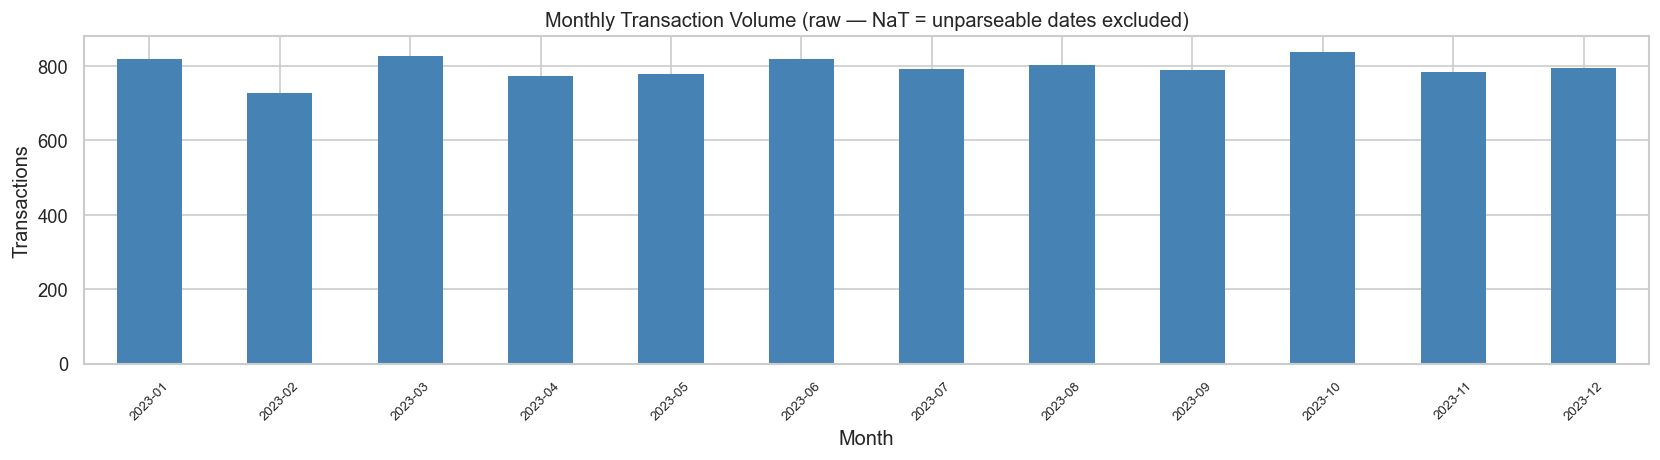

Unparseable date rows: 460


In [70]:
# ── 3c. Transaction volume over time (raw dates) ──────────────────────────────
date_counts = (
    df["Transaction Date"]
    .pipe(lambda s: pd.to_datetime(s, errors="coerce"))
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
date_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="none")
ax.set_title("Monthly Transaction Volume (raw — NaT = unparseable dates excluded)")
ax.set_xlabel("Month")
ax.set_ylabel("Transactions")
ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cafe_plot_raw_volume.png"), bbox_inches="tight")
plt.show()
print(f"Unparseable date rows: {df['Transaction Date'].pipe(lambda s: pd.to_datetime(s, errors='coerce')).isna().sum():,}")

## 4. Missing & Dirty Value Analysis

The dataset uses **four different representations of "no data"**:
- empty string `""`
- literal `"UNKNOWN"`
- literal `"ERROR"`
- `NaN` (true pandas null — rare since we loaded as strings)

We normalise all of them to `NaN` so pandas's standard missing-value tools work correctly.

In [71]:
# ── Sentinel values that mean "missing" in this dataset ──────────────────────
DIRTY_SENTINELS = {"", "UNKNOWN", "ERROR", "NULL", "N/A", "NAN", "NONE"}

# Replace sentinels with NaN across the whole frame
df.replace(list(DIRTY_SENTINELS), np.nan, inplace=True)

# ── Missing-value table (after sentinel normalisation) ────────────────────────
missing = df.isnull().sum().rename("count").to_frame()
missing["pct"] = (missing["count"] / len(df) * 100).round(2)
missing = missing[missing["count"] > 0].sort_values("pct", ascending=False)

print("Missing values after sentinel normalisation:\n")
display(
    missing.style
           .bar(subset=["pct"], color="#f87171")
           .format({"pct": "{:.1f}%"})
)

Missing values after sentinel normalisation:



,count,pct
Location,3961,39.6%
Payment Method,3178,31.8%
Item,969,9.7%
Price Per Unit,533,5.3%
Transaction Time,509,5.1%
Total Spent,502,5.0%
Quantity,479,4.8%
Transaction Date,460,4.6%


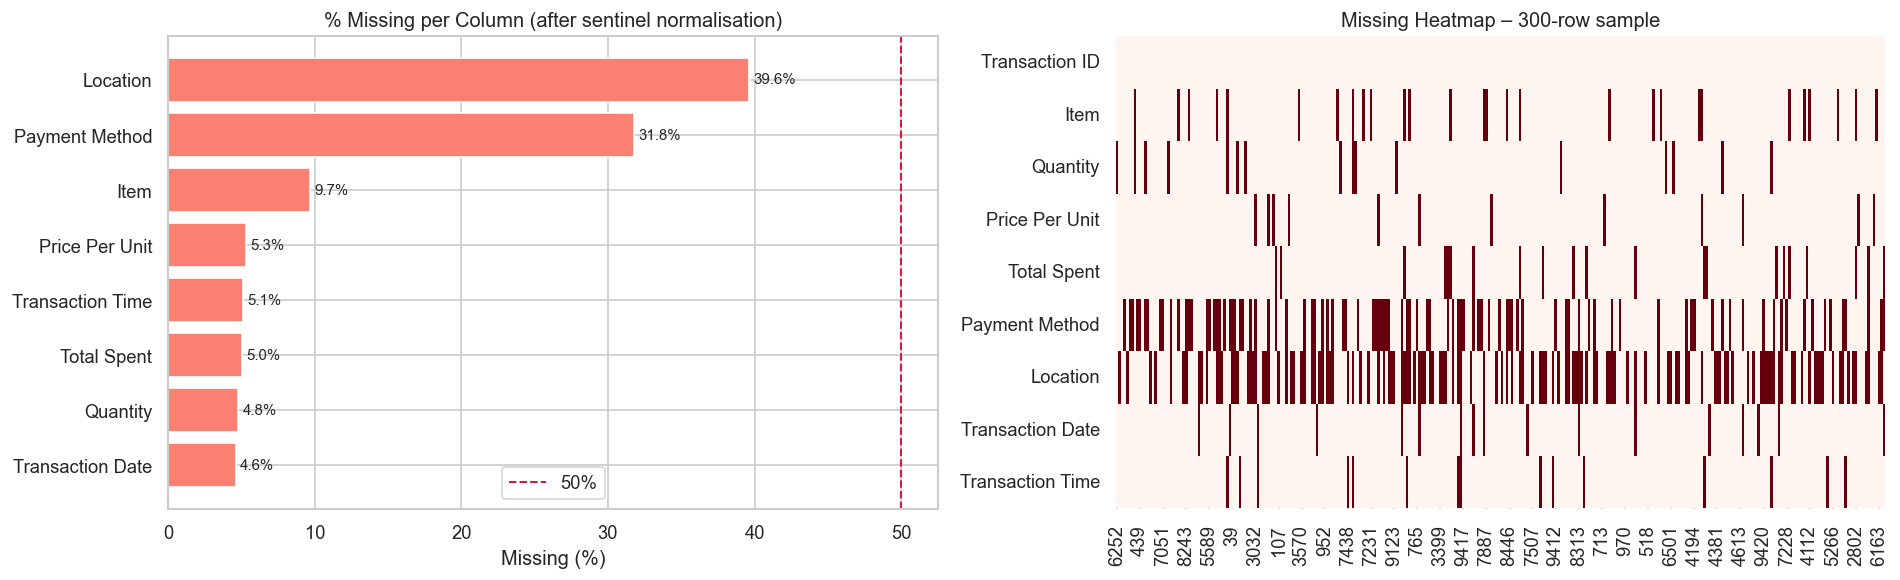

Saved → ./data_preprocessing_outputs/cafe_plot_missing_before.png


In [72]:
# ── Missing-value bar chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(missing.index[::-1], missing["pct"][::-1], color="salmon")
axes[0].set_xlabel("Missing (%)")
axes[0].set_title("% Missing per Column (after sentinel normalisation)")
axes[0].axvline(50, color="crimson", linestyle="--", linewidth=1.2, label="50%")
axes[0].legend()
for i, (col, row) in enumerate(missing.iloc[::-1].iterrows()):
    axes[0].text(row["pct"] + 0.3, i, f"{row['pct']:.1f}%", va="center", fontsize=9)


sample = df.sample(min(300, len(df)), random_state=42)
sns.heatmap(sample.isnull().T, cbar=False, ax=axes[1], cmap="Reds")
axes[1].set_title("Missing Heatmap – 300-row sample")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cafe_plot_missing_before.png"), bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {os.path.join(OUTPUT_DIR, 'cafe_plot_missing_before.png')}")

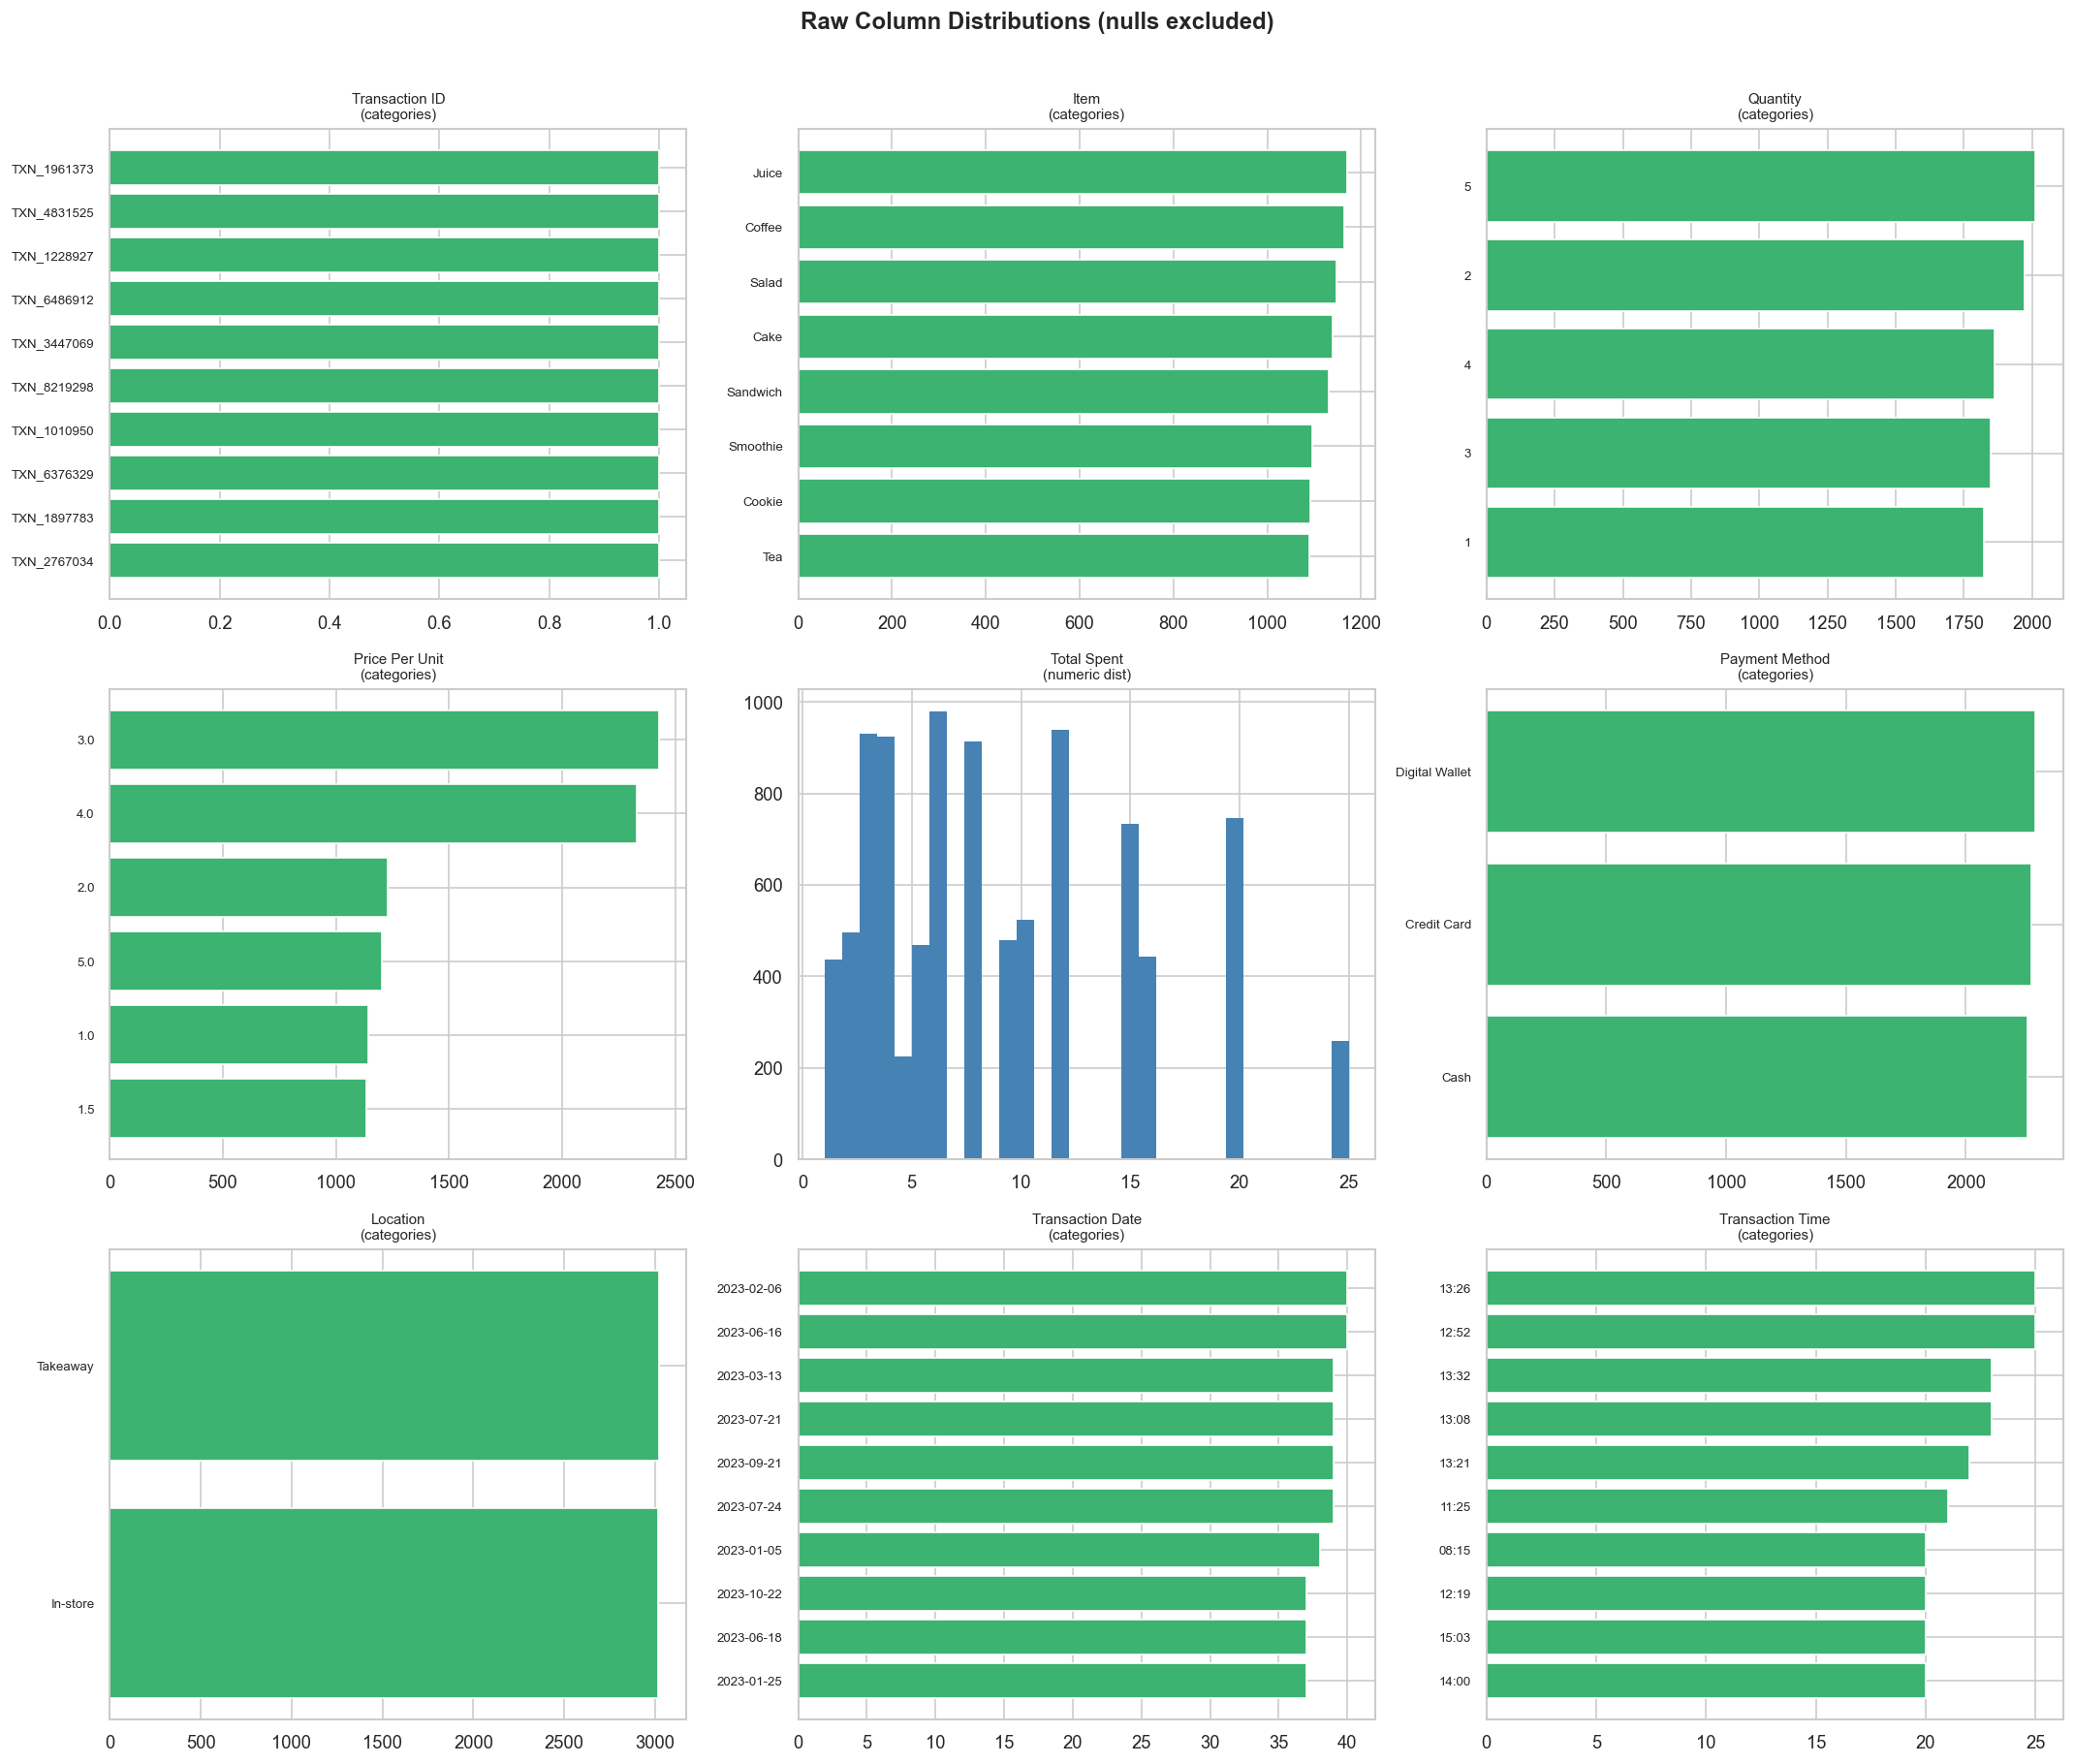

Saved → ./data_preprocessing_outputs/cafe_plot_raw_distributions.png


In [73]:
# ── Raw distribution plots for every column ───────────────────────────────────
ncols = len(df.columns)
nrows = -(-ncols // 3)          # ceiling division → 3 columns per row
fig, axes = plt.subplots(nrows, 3, figsize=(18, 5 * nrows))
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    ax = axes[idx]
    non_null = df[col].dropna()
    numeric  = pd.to_numeric(non_null, errors="coerce").dropna()

    if len(numeric) > 0 and numeric.nunique() > 6:
        ax.hist(numeric, bins=30, color="steelblue", edgecolor="none")
        ax.set_title(f"{col}\n(numeric dist)", fontsize=9)
    else:
        vc = non_null.value_counts().head(10)
        ax.barh(vc.index.astype(str)[::-1], vc.values[::-1], color="mediumseagreen")
        ax.set_title(f"{col}\n(categories)", fontsize=9)
        ax.tick_params(axis="y", labelsize=8)

# Hide any unused axes
for ax in axes[ncols:]:
    ax.set_visible(False)

fig.suptitle("Raw Column Distributions (nulls excluded)", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cafe_plot_raw_distributions.png"), bbox_inches="tight")
plt.show()
print(f"Saved → {os.path.join(OUTPUT_DIR, 'cafe_plot_raw_distributions.png')}")

## 5. Type Casting & Parsing

Now we cast each column to its intended type:
- `Quantity`, `Price Per Unit`, `Total Spent` → `float` (coerce strings to NaN)
- `Transaction Date` → `datetime`
- `Transaction Time` → parsed to a proper `datetime` (time component only), hour extracted as integer
- `Item`, `Payment Method`, `Location` → `category`


In [74]:
# Numeric columns
for col in ["Quantity", "Price Per Unit", "Total Spent"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Date column
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

# Time column — parse "HH:MM" strings; extract hour as int for later use
_time_parsed = pd.to_datetime(df["Transaction Time"], format="%H:%M", errors="coerce")
df["Transaction Time"] = _time_parsed          # keep as datetime (time component)
df["hour"] = _time_parsed.dt.hour              # integer 6–22, NaN where dirty

# Categorical columns
for col in ["Item", "Payment Method", "Location"]:
    df[col] = df[col].astype("category")

print("Types after casting:")
print(df.dtypes)
print(f"\nNulls after casting: {df.isnull().sum().sum():,}")
df.head(5)

Types after casting:
Transaction ID              object
Item                      category
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method            category
Location                  category
Transaction Date    datetime64[ns]
Transaction Time    datetime64[ns]
hour                       float64
dtype: object

Nulls after casting: 11,100


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Transaction Time,hour
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,1900-01-01 15:01:00,15.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,1900-01-01 10:08:00,10.0
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19,1900-01-01 16:57:00,16.0
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27,NaT,NaN
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,NaT,NaN


## 6. Handle Missing Values

**Strategy per column:**

| Column | Strategy | Rationale |
|---|---|---|
| `Item` | Mode imputation | Only a few menu items; most-common is a reasonable default |
| `Quantity` | Median imputation | Integer 1–5; median is robust to mild skew |
| `Price Per Unit` | **Mean per Item (two-pass)** | Each item has a near-fixed price; we build a per-item mean lookup. A second pass runs after `Item` nulls are filled so every row is covered — no missing values remain |
| `Total Spent` | Recalculate from `Quantity × Price Per Unit` | More accurate than imputing a raw number; recalculated twice to capture values resolved after each pass |
| `Payment Method` | Mode imputation | No business rule links payment method to other columns |
| `Location` | Mode imputation | Same rationale |
| `Transaction Date` | Drop rows | Dates can't be reliably reconstructed; only ~3 % affected |
| `Transaction Time` | Median hour imputation | ~5 % dirty; median hour preserves the realistic time distribution |


In [75]:
before_rows = len(df)

# ── 6a. Build item → mean price reference table ───────────────────────────────
# Use mean so the imputed value reflects the average selling price per item.
item_price_map = (
    df.dropna(subset=["Item", "Price Per Unit"])
      .groupby("Item", observed=True)["Price Per Unit"]
      .mean()
      .to_dict()
)
print("Item → mean price reference table:")
for item, price in sorted(item_price_map.items()):
    print(f"  {item:12s}  ${price:.2f}")

# ── 6b. First pass: fill Price Per Unit where Item is already known ───────────
mask_price = df["Price Per Unit"].isna() & df["Item"].notna()
df.loc[mask_price, "Price Per Unit"] = df.loc[mask_price, "Item"].map(item_price_map)
print(f"\nPrice Per Unit nulls filled (pass 1): {mask_price.sum():,}")

# ── 6c. Recalculate Total Spent = Quantity × Price Per Unit ──────────────────
recalc_mask = df["Total Spent"].isna() & df["Quantity"].notna() & df["Price Per Unit"].notna()
df.loc[recalc_mask, "Total Spent"] = (
    df.loc[recalc_mask, "Quantity"] * df.loc[recalc_mask, "Price Per Unit"]
)
print(f"Total Spent nulls recalculated (pass 1): {recalc_mask.sum():,}")

# ── 6d. Fill Item with mode ───────────────────────────────────────────────────
item_mode = df["Item"].mode()[0]
item_null_count = df["Item"].isna().sum()
df["Item"] = df["Item"].cat.add_categories([item_mode]) if item_mode not in df["Item"].cat.categories else df["Item"]
df["Item"].fillna(item_mode, inplace=True)
print(f"Item nulls filled with mode ('{item_mode}'): {item_null_count:,}")

# ── 6e. Second pass: fill any Price Per Unit still null after Item is complete ─
# Rows that had a null Item in step 6b now have an Item value → re-apply lookup.
mask_price2 = df["Price Per Unit"].isna()
df.loc[mask_price2, "Price Per Unit"] = df.loc[mask_price2, "Item"].map(item_price_map)
print(f"Price Per Unit nulls filled (pass 2, post-Item imputation): {mask_price2.sum():,}")

# ── 6f. Fill Quantity with median ─────────────────────────────────────────────
qty_median = df["Quantity"].median()
qty_null_count = df["Quantity"].isna().sum()
df["Quantity"].fillna(qty_median, inplace=True)
print(f"Quantity nulls filled with median ({qty_median:.0f}): {qty_null_count:,}")

# ── 6g. Fill Payment Method and Location with mode ───────────────────────────
for col in ["Payment Method", "Location"]:
    mode_val = df[col].mode()[0]
    null_cnt  = df[col].isna().sum()
    df[col].fillna(mode_val, inplace=True)
    print(f"{col} nulls filled with mode ('{mode_val}'): {null_cnt:,}")

# ── 6h. Recalculate Total Spent again now that Quantity/Price are fully filled ─
recalc_mask2 = df["Total Spent"].isna() & df["Quantity"].notna() & df["Price Per Unit"].notna()
df.loc[recalc_mask2, "Total Spent"] = (
    df.loc[recalc_mask2, "Quantity"] * df.loc[recalc_mask2, "Price Per Unit"]
)
print(f"Total Spent nulls recalculated (pass 2): {recalc_mask2.sum():,}")

# ── 6i. Drop rows where Transaction Date is still NaN ────────────────────────
date_null_before = df["Transaction Date"].isna().sum()
df.dropna(subset=["Transaction Date"], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nRows dropped (no Transaction Date): {date_null_before:,}")

# ── 6j. Fill Transaction Time nulls — impute with median hour ────────────────
time_null_count = df["hour"].isna().sum()
median_hour = int(df["hour"].median())
df["hour"].fillna(median_hour, inplace=True)
_imputed_mask = df["Transaction Time"].isna()
df.loc[_imputed_mask, "Transaction Time"] = pd.to_datetime(
    df.loc[_imputed_mask, "hour"].astype(int).astype(str).str.zfill(2) + ":00",
    format="%H:%M", errors="coerce"
)
print(f"Transaction Time nulls filled with median hour ({median_hour:02d}:00): {time_null_count:,}")

# ── 6k. Any remaining Total Spent nulls → fill with item mean ────────────────
if df["Total Spent"].isna().any():
    item_total_map = df.dropna(subset=["Total Spent"]).groupby("Item", observed=True)["Total Spent"].mean()
    df["Total Spent"].fillna(df["Item"].map(item_total_map), inplace=True)

remaining = df.isnull().sum().sum()
print(f"\nTotal remaining nulls: {remaining}")
print(f"Rows: {before_rows:,} → {len(df):,}  (lost {before_rows - len(df):,})")

Item → mean price reference table:
  Cake          $3.00
  Coffee        $2.00
  Cookie        $1.00
  Juice         $3.00
  Salad         $5.00
  Sandwich      $4.00
  Smoothie      $4.00
  Tea           $1.50

Price Per Unit nulls filled (pass 1): 479
Total Spent nulls recalculated (pass 1): 479
Item nulls filled with mode ('Juice'): 969
Price Per Unit nulls filled (pass 2, post-Item imputation): 54
Quantity nulls filled with median (3): 479
Payment Method nulls filled with mode ('Digital Wallet'): 3,178
Location nulls filled with mode ('Takeaway'): 3,961
Total Spent nulls recalculated (pass 2): 23

Rows dropped (no Transaction Date): 460
Transaction Time nulls filled with median hour (13:00): 476

Total remaining nulls: 0
Rows: 10,000 → 9,540  (lost 460)


/var/folders/ww/b3p6vfwd1t54rp1szn5gk4580000gn/T/ipykernel_4729/3831666430.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Item"].fillna(item_mode, inplace=True)
/var/folders/ww/b3p6vfwd1t54rp1szn5gk4580000gn/T/ipykernel_4729/3831666430.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

## 7. Remove Duplicates

In [76]:
pre_dedup = len(df)

# Full-row duplicates
full_dupes = df.duplicated().sum()
df.drop_duplicates(inplace=True)

# Duplicate Transaction IDs (keep first)
txn_dupes = df.duplicated(subset=["Transaction ID"]).sum()
df.drop_duplicates(subset=["Transaction ID"], keep="first", inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Full duplicate rows removed : {full_dupes:,}")
print(f"Duplicate Transaction IDs  : {txn_dupes:,}")
print(f"Rows: {pre_dedup:,} → {len(df):,}")

Full duplicate rows removed : 0
Duplicate Transaction IDs  : 0
Rows: 9,540 → 9,540


## 8. Outlier Detection & Removal

We check `Quantity`, `Price Per Unit`, and `Total Spent` for extreme values using IQR capping.

Quantity              [-1.00, 7.00]  capped: 0
Price Per Unit        [-1.00, 7.00]  capped: 0
Total Spent           [-8.00, 24.00]  capped: 260


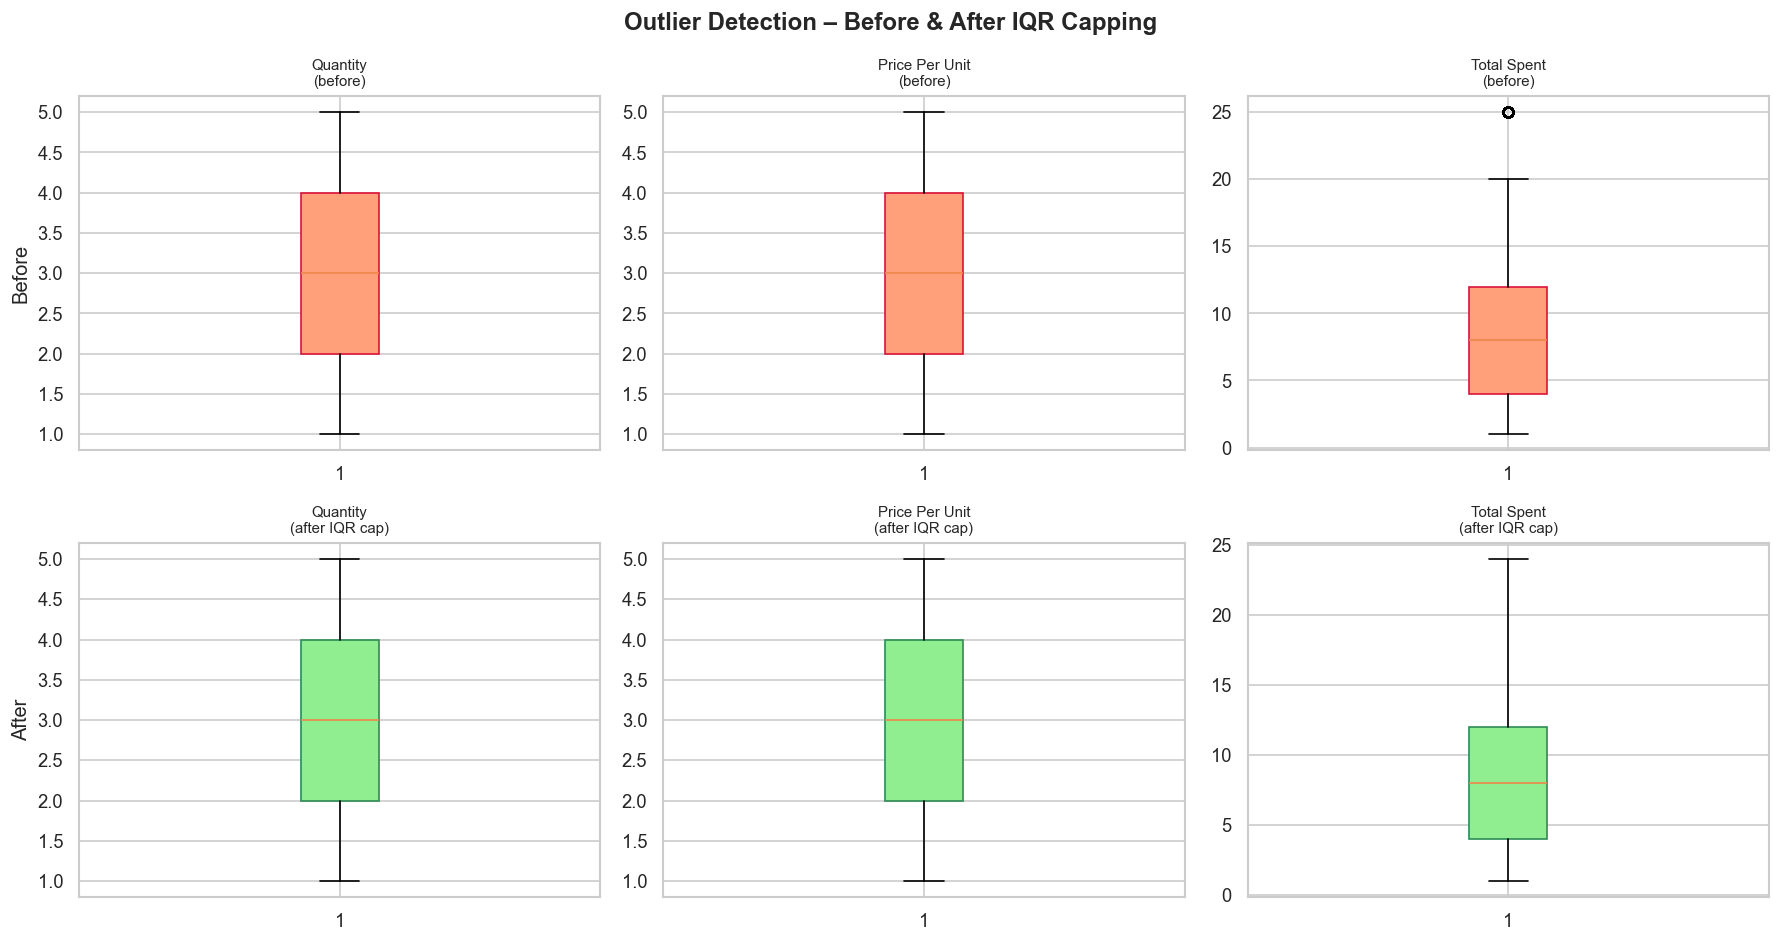

Saved → ./data_preprocessing_outputs/cafe_plot_outliers.png


In [77]:
OUTLIER_COLS = ["Quantity", "Price Per Unit", "Total Spent"]
n = len(OUTLIER_COLS)

fig, axes = plt.subplots(2, n, figsize=(5 * n, 8))

for i, col in enumerate(OUTLIER_COLS):
    # Before
    axes[0][i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor="lightsalmon", color="crimson"))
    axes[0][i].set_title(f"{col}\n(before)", fontsize=9)

    # IQR capping
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_capped = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = np.clip(df[col].to_numpy(), lower, upper)
    print(f"{col:20s}  [{lower:.2f}, {upper:.2f}]  capped: {n_capped:,}")

    # After
    axes[1][i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor="lightgreen", color="seagreen"))
    axes[1][i].set_title(f"{col}\n(after IQR cap)", fontsize=9)

axes[0][0].set_ylabel("Before")
axes[1][0].set_ylabel("After")
fig.suptitle("Outlier Detection – Before & After IQR Capping", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cafe_plot_outliers.png"), bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {os.path.join(OUTPUT_DIR, 'cafe_plot_outliers.png')}")

## 9. Feature Engineering

New features derived from the existing columns that will be useful for analysis and modelling:

In [78]:
# ── Date-derived features ─────────────────────────────────────────────────────
df["year"]        = df["Transaction Date"].dt.year
df["month"]       = df["Transaction Date"].dt.month
df["day_of_week"] = df["Transaction Date"].dt.dayofweek   # 0=Mon, 6=Sun
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)
df["quarter"]     = df["Transaction Date"].dt.quarter

# ── Time-derived features ─────────────────────────────────────────────────────
# hour is already set in Section 5; derive a bucketed time_of_day label
def _time_of_day(h):
    if   h <  0: return "unknown"
    elif h < 12: return "morning"    # 06:00 – 11:59
    elif h < 17: return "afternoon"  # 12:00 – 16:59
    else:        return "evening"    # 17:00 – 22:59

df["time_of_day"] = df["hour"].apply(_time_of_day).astype("category")

# ── Revenue consistency check ─────────────────────────────────────────────────
df["expected_total"] = (df["Quantity"] * df["Price Per Unit"]).round(2)
df["total_mismatch"] = (
    (df["Total Spent"] - df["expected_total"]).abs() > 0.01
).astype(int)
print(f"Rows with Total Spent ≠ Qty × Price: {df['total_mismatch'].sum():,}")

df.loc[df["total_mismatch"] == 1, "Total Spent"] = df.loc[df["total_mismatch"] == 1, "expected_total"]
df.drop(columns=["expected_total", "total_mismatch"], inplace=True)

# ── Payment method encoding (one-hot) ─────────────────────────────────────────
df["is_cash"]           = (df["Payment Method"] == "Cash").astype(int)
df["is_credit_card"]    = (df["Payment Method"] == "Credit Card").astype(int)
df["is_digital_wallet"] = (df["Payment Method"] == "Digital Wallet").astype(int)

# ── Location flag ─────────────────────────────────────────────────────────────
df["is_takeaway"] = (df["Location"] == "Takeaway").astype(int)

new_features = ["year", "month", "day_of_week", "is_weekend", "quarter",
                "hour", "time_of_day",
                "is_cash", "is_credit_card", "is_digital_wallet", "is_takeaway"]
print(f"New features: {new_features}")
df[new_features].head(3)

Rows with Total Spent ≠ Qty × Price: 622
New features: ['year', 'month', 'day_of_week', 'is_weekend', 'quarter', 'hour', 'time_of_day', 'is_cash', 'is_credit_card', 'is_digital_wallet', 'is_takeaway']


,year,month,day_of_week,is_weekend,quarter,hour,time_of_day,is_cash,is_credit_card,is_digital_wallet,is_takeaway
0,2023,9,4,0,3,15.0,afternoon,0,1,0,1
1,2023,5,1,0,2,10.0,morning,1,0,0,0
2,2023,7,2,0,3,16.0,afternoon,0,1,0,0


## 10. Post-Cleaning Exploration & Visualizations

Now that the data is clean, we explore the domain in depth to understand sales patterns.

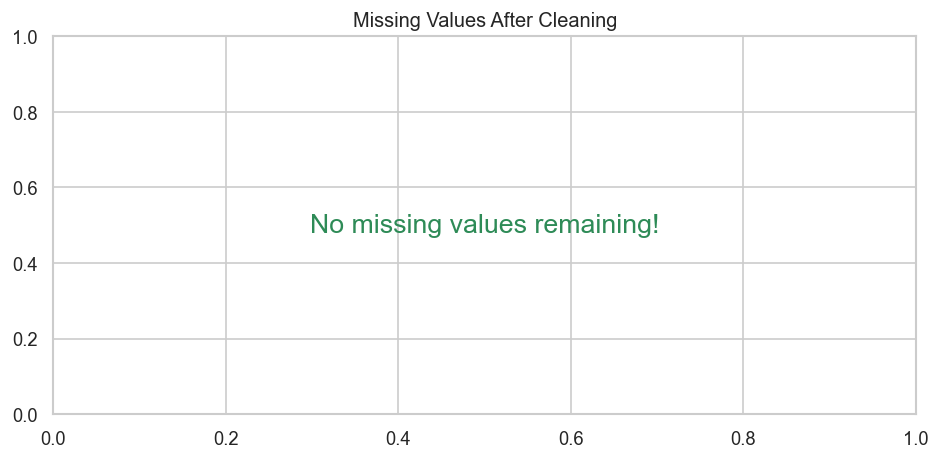

In [79]:
# ── 10a. Confirm no missing values remain ────────────────────────────────────
post_null = df.isnull().sum()
post_null = post_null[post_null > 0]
fig, ax = plt.subplots(figsize=(8, 4))
if len(post_null) == 0:
    ax.text(0.5, 0.5, "No missing values remaining!", ha="center", va="center",
            fontsize=16, color="seagreen", transform=ax.transAxes)
else:
    ax.barh(post_null.index, post_null.values, color="salmon")
    ax.set_xlabel("Count")
ax.set_title("Missing Values After Cleaning")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cafe_plot_missing_after.png"), bbox_inches="tight")
plt.show()

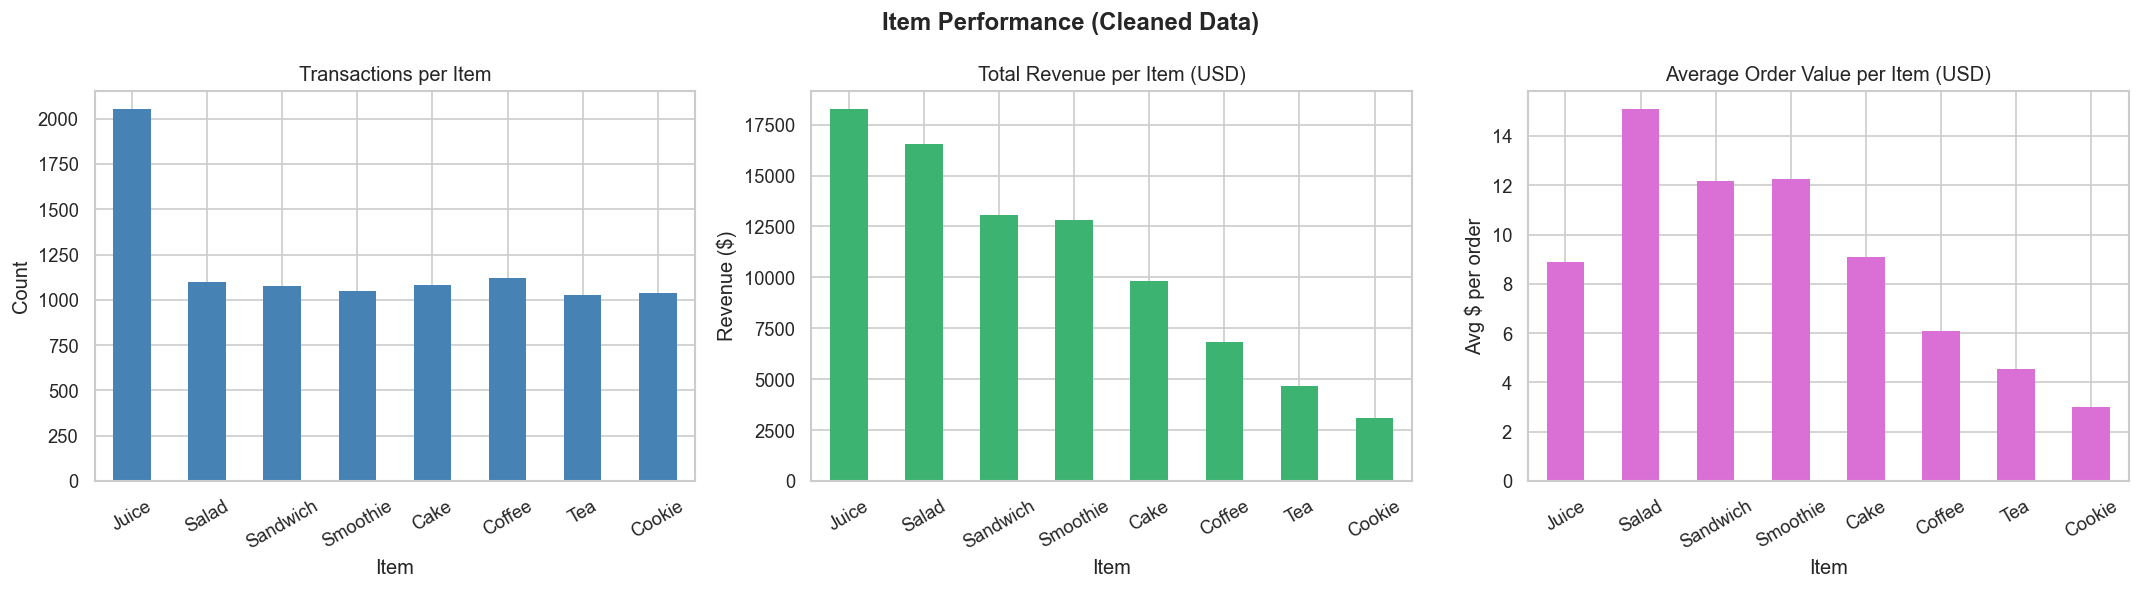

Saved → ./data_preprocessing_outputs/cafe_plot_item_performance.png


,transactions,total_revenue,avg_order_value
Item,,,
Juice,2051,"$18,249.00",$8.90
Salad,1099,"$16,570.00",$15.08
Sandwich,1075,"$13,064.00",$12.15
Smoothie,1048,"$12,832.00",$12.24
Cake,1082,"$9,834.00",$9.09
Coffee,1123,"$6,850.00",$6.10
Tea,1027,"$4,687.50",$4.56
Cookie,1035,"$3,093.00",$2.99


In [80]:
# ── 10b. Revenue & transactions per item ─────────────────────────────────────
item_stats = (
    df.groupby("Item", observed=True)
      .agg(transactions=("Transaction ID", "count"),
           total_revenue=("Total Spent", "sum"),
           avg_order_value=("Total Spent", "mean"))
      .sort_values("total_revenue", ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

item_stats["transactions"].plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("Transactions per Item")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

item_stats["total_revenue"].plot(kind="bar", ax=axes[1], color="mediumseagreen", edgecolor="none")
axes[1].set_title("Total Revenue per Item (USD)")
axes[1].set_ylabel("Revenue ($)")
axes[1].tick_params(axis="x", rotation=30)

item_stats["avg_order_value"].plot(kind="bar", ax=axes[2], color="orchid", edgecolor="none")
axes[2].set_title("Average Order Value per Item (USD)")
axes[2].set_ylabel("Avg $ per order")
axes[2].tick_params(axis="x", rotation=30)

fig.suptitle("Item Performance (Cleaned Data)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cafe_plot_item_performance.png"), bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {os.path.join(OUTPUT_DIR, 'cafe_plot_item_performance.png')}")
display(item_stats.style.format({"total_revenue": "${:,.2f}", "avg_order_value": "${:.2f}"})
                 .background_gradient(subset=["total_revenue"], cmap="Greens"))

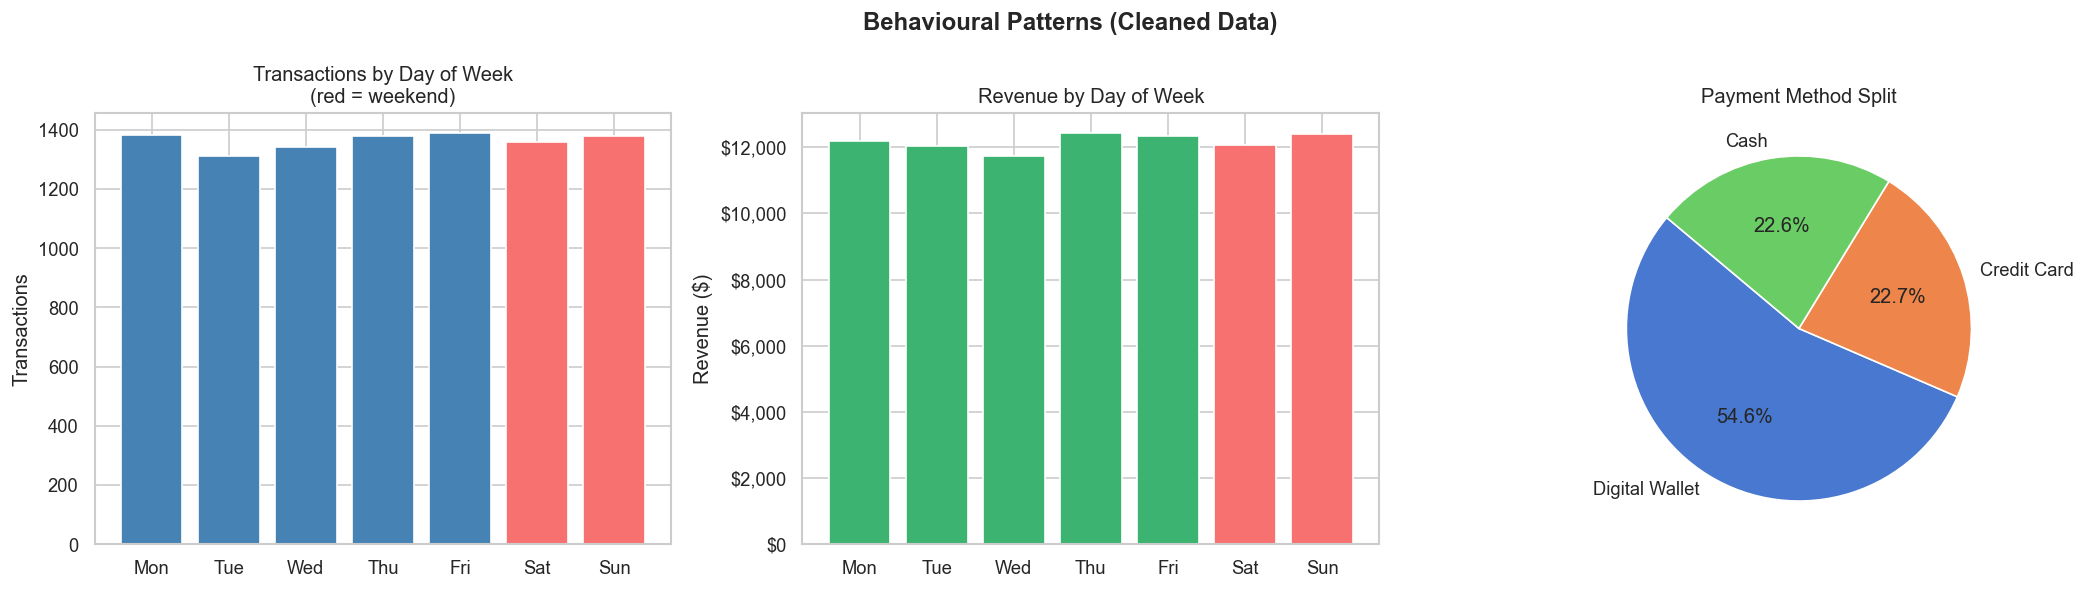

Saved → ./data_preprocessing_outputs/cafe_plot_patterns.png


In [81]:
# ── 10d. Day-of-week & weekend patterns ──────────────────────────────────────
DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Transactions per day of week
dow_tx = df.groupby("day_of_week")["Transaction ID"].count()
axes[0].bar(DAY_NAMES, dow_tx.values, color=["#f87171" if d >= 5 else "steelblue" for d in range(7)])
axes[0].set_title("Transactions by Day of Week\n(red = weekend)")
axes[0].set_ylabel("Transactions")

# Revenue per day of week
dow_rev = df.groupby("day_of_week")["Total Spent"].sum()
axes[1].bar(DAY_NAMES, dow_rev.values, color=["#f87171" if d >= 5 else "mediumseagreen" for d in range(7)])
axes[1].set_title("Revenue by Day of Week")
axes[1].set_ylabel("Revenue ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Payment method split
pm_counts = df["Payment Method"].value_counts()
axes[2].pie(pm_counts.values, labels=pm_counts.index, autopct="%1.1f%%",
            startangle=140, colors=sns.color_palette("muted", len(pm_counts)))
axes[2].set_title("Payment Method Split")

fig.suptitle("Behavioural Patterns (Cleaned Data)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cafe_plot_patterns.png"), bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {os.path.join(OUTPUT_DIR, 'cafe_plot_patterns.png')}")

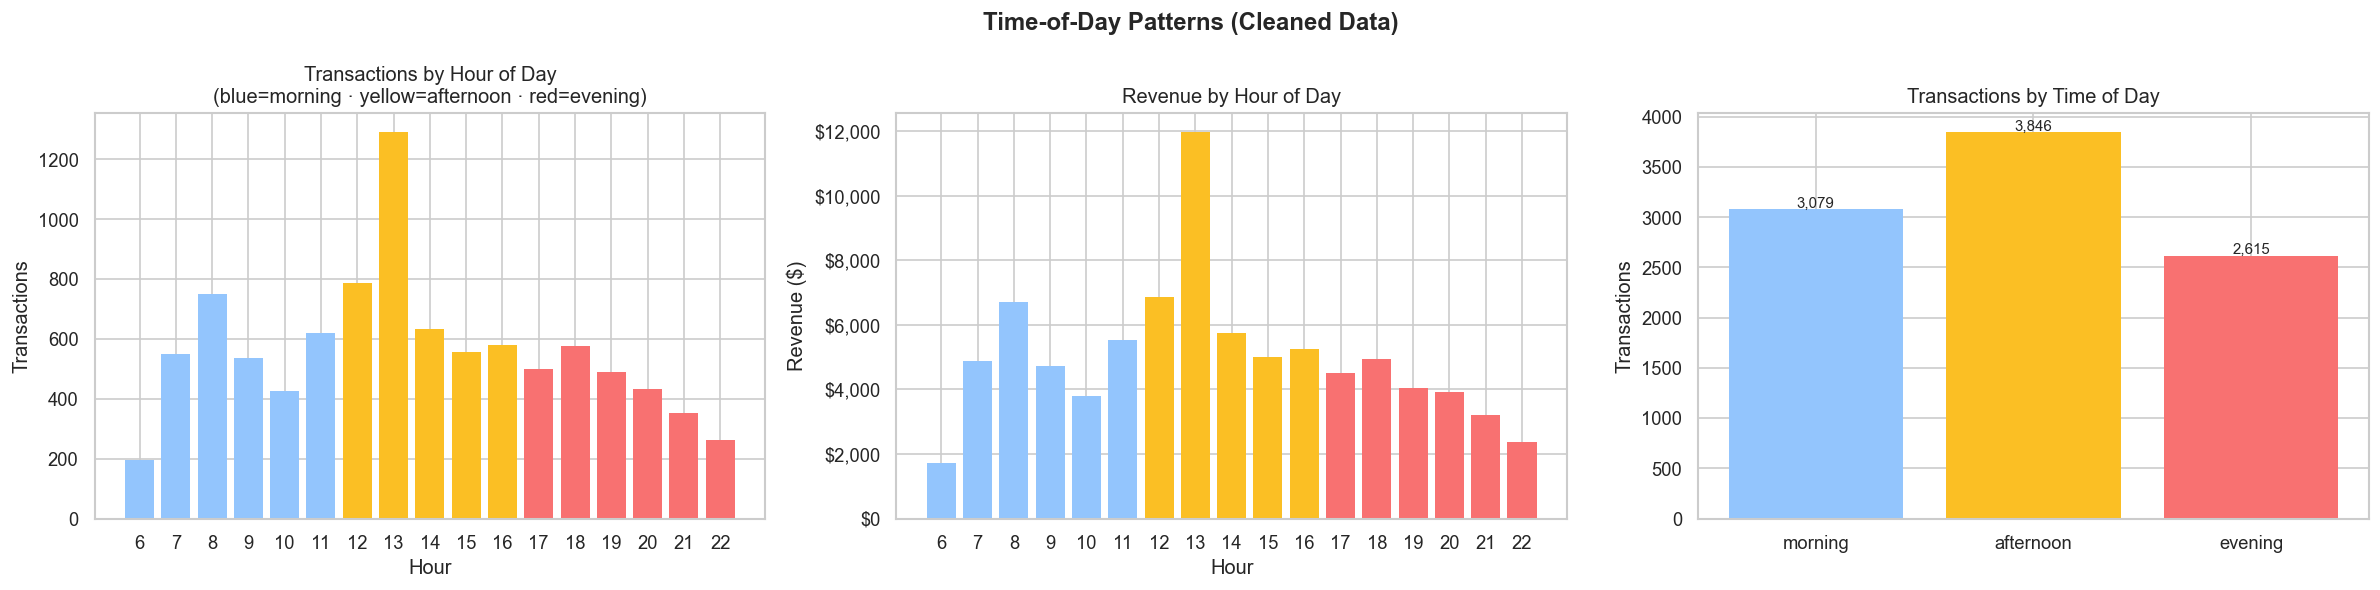

Saved → ./data_preprocessing_outputs/cafe_plot_time_of_day.png


In [82]:
# ── 10e. Time-of-day patterns ─────────────────────────────────────────────────
HOURS = list(range(6, 23))    # 6 AM – 10 PM

hourly_tx  = df.groupby("hour")["Transaction ID"].count().reindex(HOURS, fill_value=0)
hourly_rev = df.groupby("hour")["Total Spent"].sum().reindex(HOURS, fill_value=0)
tod_tx     = df["time_of_day"].value_counts().reindex(["morning", "afternoon", "evening"])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Transactions per hour
bar_colors = ["#93c5fd" if h < 12 else "#fbbf24" if h < 17 else "#f87171" for h in HOURS]
axes[0].bar(HOURS, hourly_tx.values, color=bar_colors, edgecolor="none")
axes[0].set_title("Transactions by Hour of Day\n(blue=morning · yellow=afternoon · red=evening)")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Transactions")
axes[0].set_xticks(HOURS)

# Revenue per hour
axes[1].bar(HOURS, hourly_rev.values, color=bar_colors, edgecolor="none")
axes[1].set_title("Revenue by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Revenue ($)")
axes[1].set_xticks(HOURS)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Time-of-day bucket split
axes[2].bar(tod_tx.index, tod_tx.values,
            color=["#93c5fd", "#fbbf24", "#f87171"], edgecolor="none")
axes[2].set_title("Transactions by Time of Day")
axes[2].set_ylabel("Transactions")
for i, v in enumerate(tod_tx.values):
    axes[2].text(i, v + 20, f"{v:,}", ha="center", fontsize=9)

fig.suptitle("Time-of-Day Patterns (Cleaned Data)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cafe_plot_time_of_day.png"), bbox_inches="tight")
plt.show()
print(f"Saved → {os.path.join(OUTPUT_DIR, 'cafe_plot_time_of_day.png')}")

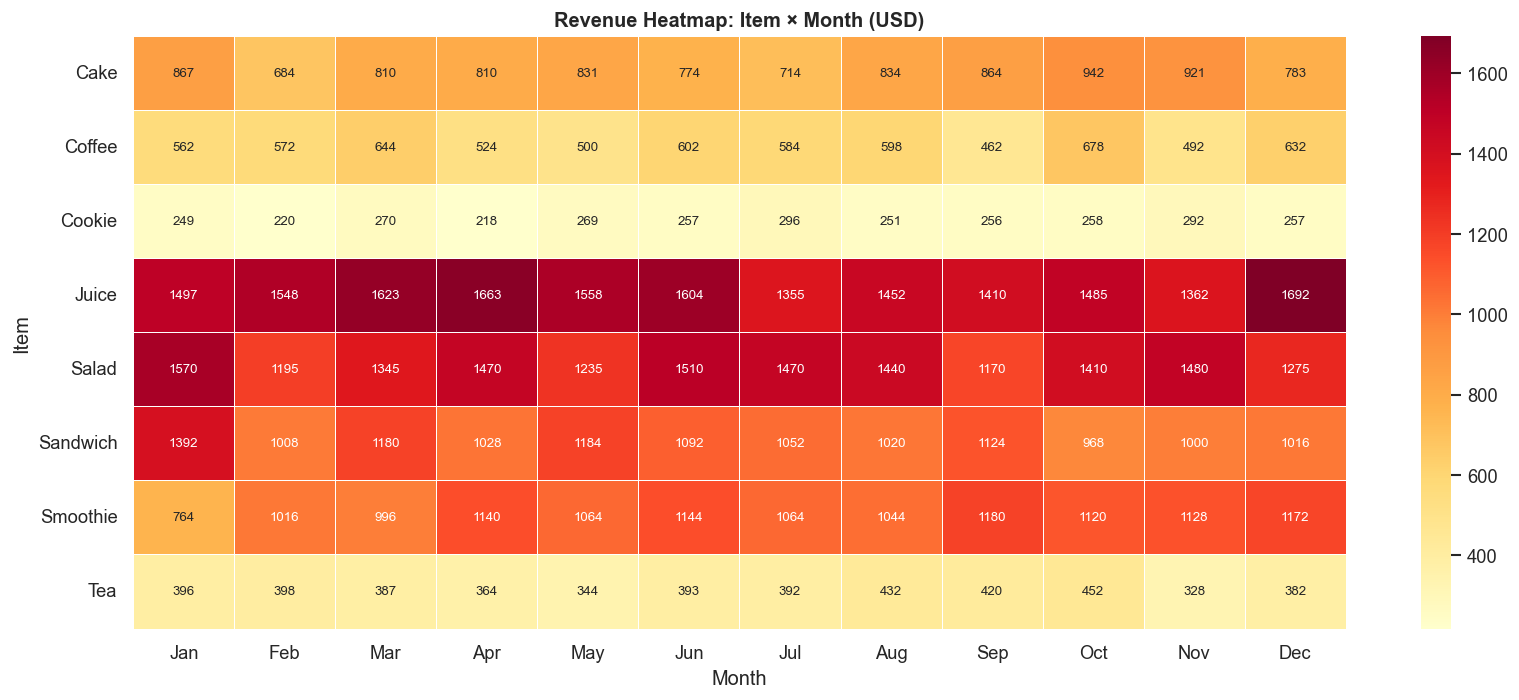

Saved → ./data_preprocessing_outputs/cafe_plot_item_month_heatmap.png


In [83]:
# ── 10e. Item revenue heatmap: item × month ───────────────────────────────────
item_month = (
    df.groupby(["Item", "month"], observed=True)["Total Spent"]
      .sum()
      .unstack(fill_value=0)
)
item_month.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                      "Jul","Aug","Sep","Oct","Nov","Dec"][:len(item_month.columns)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(item_month, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.4, ax=ax, annot_kws={"size": 8})
ax.set_title("Revenue Heatmap: Item × Month (USD)", fontweight="bold")
ax.set_ylabel("Item")
ax.set_xlabel("Month")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cafe_plot_item_month_heatmap.png"), bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {os.path.join(OUTPUT_DIR, 'cafe_plot_item_month_heatmap.png')}")

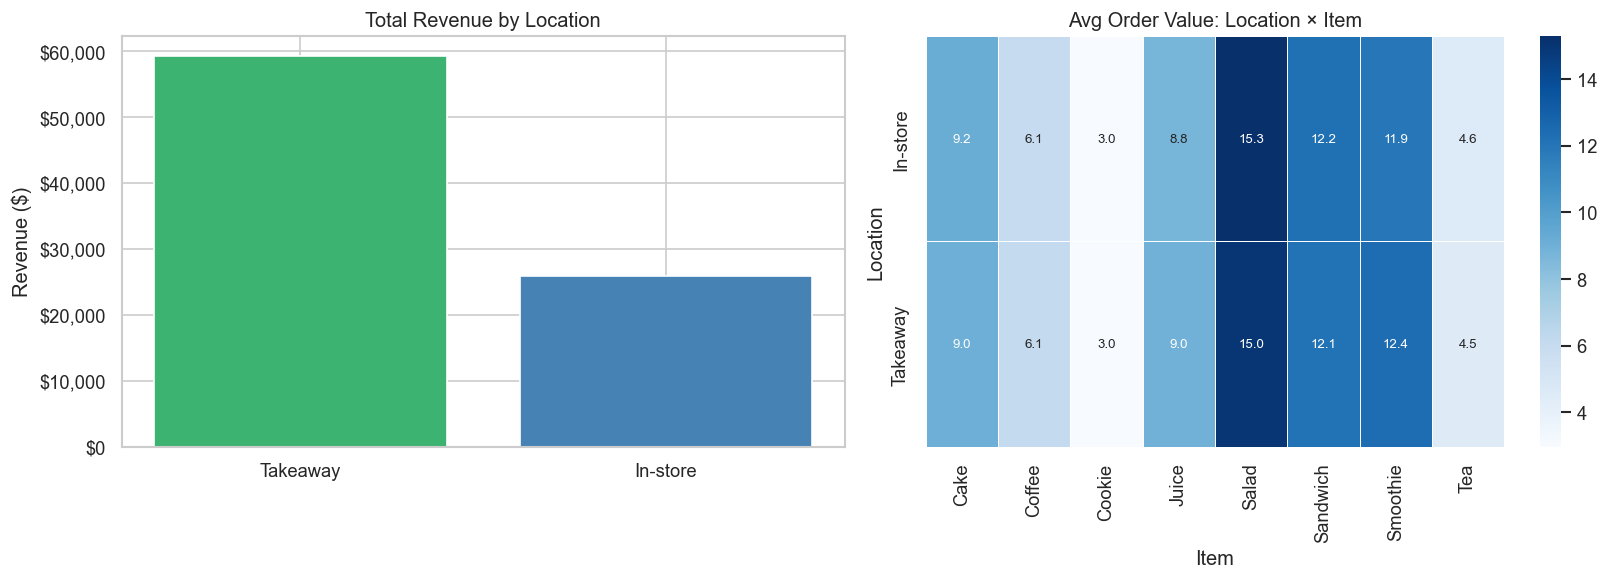

Saved → ./data_preprocessing_outputs/cafe_plot_location.png


In [84]:
# ── 10f. Location breakdown ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

loc_rev = df.groupby("Location", observed=True)["Total Spent"].sum().sort_values(ascending=False)
axes[0].bar(loc_rev.index, loc_rev.values,
            color=["steelblue" if l == "In-store" else "mediumseagreen" for l in loc_rev.index])
axes[0].set_title("Total Revenue by Location")
axes[0].set_ylabel("Revenue ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Avg order value per location per item
loc_item = (
    df.groupby(["Location", "Item"], observed=True)["Total Spent"]
      .mean()
      .unstack(fill_value=0)
)
sns.heatmap(loc_item, annot=True, fmt=".1f", cmap="Blues",
            linewidths=0.4, ax=axes[1], annot_kws={"size": 8})
axes[1].set_title("Avg Order Value: Location × Item")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cafe_plot_location.png"), bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {os.path.join(OUTPUT_DIR, 'cafe_plot_location.png')}")

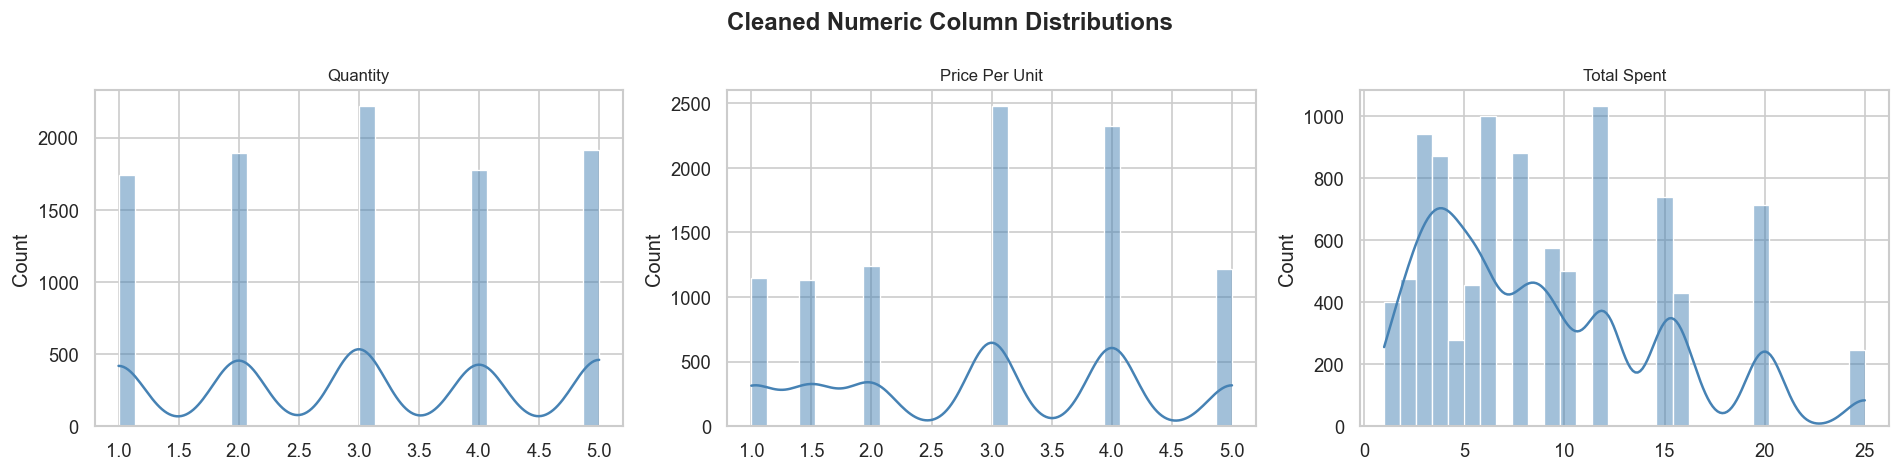

Saved → ./data_preprocessing_outputs/cafe_plot_cleaned_distributions.png


In [85]:
# ── 10g. Numeric distributions (cleaned) ─────────────────────────────────────
num_cols_clean = ["Quantity", "Price Per Unit", "Total Spent"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols_clean):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
fig.suptitle("Cleaned Numeric Column Distributions", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cafe_plot_cleaned_distributions.png"), bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {os.path.join(OUTPUT_DIR, 'cafe_plot_cleaned_distributions.png')}")

## 11. Export Cleaned Dataset

In [86]:
OUTPUT_PATH = os.path.join(os.path.dirname(CSV_PATH), "cafe_sales_cleaned.csv")

# Convert categoricals back to string for portability
export_df = df.copy()
for col in export_df.select_dtypes("category").columns:
    export_df[col] = export_df[col].astype(str)

export_df.to_csv(OUTPUT_PATH, index=False)

print("=" * 60)
print(f"  Cleaned dataset saved  →  {OUTPUT_PATH}")
print("=" * 60)
print(f"\n  Original rows  : {len(df_raw):,}")
print(f"  Cleaned rows   : {len(export_df):,}  ({len(df_raw)-len(export_df):,} dropped)")
print(f"  Columns        : {export_df.shape[1]}  ({df_raw.shape[1]} original + {export_df.shape[1]-df_raw.shape[1]} engineered)")
print(f"  Missing values : {export_df.isnull().sum().sum()}")
print(f"\n  Columns in output:")
for col in export_df.columns:
    print(f"    {col:30s}  {export_df[col].dtype}")

  Cleaned dataset saved  →  ./datasets/cafe_sales_cleaned.csv

  Original rows  : 10,000
  Cleaned rows   : 9,540  (460 dropped)
  Columns        : 20  (9 original + 11 engineered)
  Missing values : 0

  Columns in output:
    Transaction ID                  object
    Item                            object
    Quantity                        float64
    Price Per Unit                  float64
    Total Spent                     float64
    Payment Method                  object
    Location                        object
    Transaction Date                datetime64[ns]
    Transaction Time                datetime64[ns]
    hour                            float64
    year                            int32
    month                           int32
    day_of_week                     int32
    is_weekend                      int64
    quarter                         int32
    time_of_day                     object
    is_cash                         int64
    is_credit_card             